In [22]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import MNIST
from clearml import Task, Dataset
import json
import matplotlib.pyplot as plt

In [ ]:
with open("creds.json", "r") as lines:
    creds = json.load(lines)

Task.set_credentials(
    api_host=creds["api_server"],
    web_host=creds["web_server"],
    files_host=creds["files_server"],
    key=creds["access_key"],
    secret=creds["secret_key"]
)

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),                     # из [0,255] в [0,1]
    transforms.Normalize((0.1307,), (0.3081,)) # нормализация (mean=0.1307,std=0.3081)
    # Значения вычислены по всему тренировочному набору MNIST и помогают привести данные к нулевому среднему и единичному стандартному отклонению, что ускоряет и стабилизирует обучение.
])
train_data = MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = MNIST(root='./data', train=False, download=True, transform=transform) 

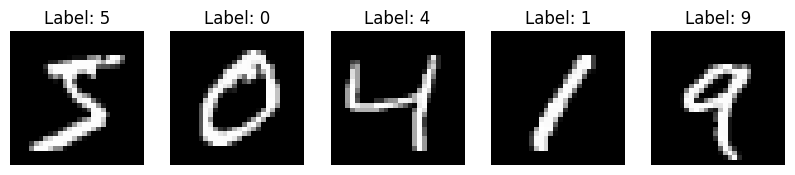

In [19]:
# Блок кода, отвечающий за визуализацию, его редактировать не надо.
fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i, ax in enumerate(axes):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()

In [21]:
train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size

train_data, val_data = random_split(train_data, [train_size, val_size]) 

images.shape: torch.Size([64, 1, 28, 28])
labels.shape: torch.Size([64])
Метка первого изображения в батче: 3


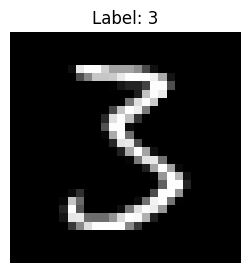

In [41]:
train_loader = DataLoader(dataset=train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset=val_data, batch_size=64, shuffle=False)

first_batch = next(iter(train_loader))

images, labels = first_batch[0], first_batch[1]


# Печатаем формы тензоров
print("images.shape:", images.shape)   # torch.Size([64, 1, 28, 28])
print("labels.shape:", labels.shape)   # torch.Size([64])


# Выведем метку первого изображения
first_label = labels[0].item()
print("Метка первого изображения в батче:", first_label)


# Отобразим само первое изображение
plt.figure(figsize=(3,3))
plt.imshow(images[0].squeeze(), cmap='gray')

plt.title(f"Label: {first_label}")
plt.axis('off')
plt.show()